# Lung-masked different-patient registration — seminar notebook

This streamlined notebook fine-tunes the completed 80k model and produces reproducible before/after registration figures for the seminar.


In [1]:
import os
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import voxelmorph as vxm
import neurite as ne
import scipy.ndimage

os.environ['VXM_BACKEND'] = 'pytorch'

backend:pytorch
Pytorch


In [2]:
# 実行デバイス
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda:0


In [3]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
# inshape = (*x_train.shape[1:], unet_input_features)

nb_features = [
    [32, 64, 64, 64, 64],
    [64, 64, 64, 64, 64, 32, 16, 16]
]


In [4]:
import math
from pathlib import Path
import torch
import matplotlib.pyplot as plt

band_names = ['LLL', 'LLH', 'LHL', 'LHH', 'HLL', 'HLH', 'HHL', 'HHH']

wavelet_vis_enabled = False
wavelet_vis_every = 100
wavelet_vis_dir = Path('wavelet_stage_outputs')
wavelet_vis_dir.mkdir(exist_ok=True)

class Haar3DAnalysisOnly(nn.Module):
    def __init__(self):
        super().__init__()

        hL = torch.tensor([1.0, 1.0], dtype=torch.float32) / math.sqrt(2.0)
        hH = torch.tensor([1.0, -1.0], dtype=torch.float32) / math.sqrt(2.0)

        filters = []
        names = []

        for z_name, z_filter in zip(['L', 'H'], [hL, hH]):
            for y_name, y_filter in zip(['L', 'H'], [hL, hH]):
                for x_name, x_filter in zip(['L', 'H'], [hL, hH]):
                    kernel = (
                        z_filter[:, None, None]
                        * y_filter[None, :, None]
                        * x_filter[None, None, :]
                    )
                    filters.append(kernel)
                    names.append(z_name + y_name + x_name)

        weight = torch.stack(filters, dim=0).unsqueeze(1)
        self.register_buffer('weight', weight)
        self.names = names

    def forward(self, x):
        x = F.pad(x, (0, 1, 0, 1, 0, 1))
        return F.conv3d(x, self.weight, stride=1, padding=0)

def analysis_filter_3d(x, analysis_layer):
    return analysis_layer(x)

def down_sampling_3d(w):
    return w[:, :, ::2, ::2, ::2]

def up_sampling_3d(w_down):
    B, C, D, H, W = w_down.shape
    w_up = torch.zeros(
        B, C, D * 2, H * 2, W * 2,
        dtype=w_down.dtype,
        device=w_down.device
    )
    w_up[:, :, ::2, ::2, ::2] = w_down
    return w_up

def make_3d_filter(fz, fy, fx):
    return fz[:, None, None] * fy[None, :, None] * fx[None, None, :]

def create_synthesis_filters(device):
    low = torch.tensor([1.0, 1.0], dtype=torch.float32, device=device) / math.sqrt(2.0)
    high = torch.tensor([1.0, -1.0], dtype=torch.float32, device=device) / math.sqrt(2.0)

    filters = torch.stack([
        make_3d_filter(low, low, low),
        make_3d_filter(low, low, high),
        make_3d_filter(low, high, low),
        make_3d_filter(low, high, high),
        make_3d_filter(high, low, low),
        make_3d_filter(high, low, high),
        make_3d_filter(high, high, low),
        make_3d_filter(high, high, high),
    ], dim=0)

    filters = torch.flip(filters, dims=[1, 2, 3]).unsqueeze(1)
    return filters

def synthesis_filter_3d(w_up, synthesis_filters):
    B, C, D, H, W = w_up.shape
    filtered_bands = []

    for i in range(C):
        band = w_up[:, i:i + 1, :, :, :]
        kernel = synthesis_filters[i:i + 1]
        filtered = F.conv3d(band, kernel, stride=1, padding=1)
        filtered = filtered[:, :, :D, :H, :W]
        filtered_bands.append(filtered)

    filtered_bands = torch.cat(filtered_bands, dim=1)
    reconstructed = torch.sum(filtered_bands, dim=1, keepdim=True)
    return reconstructed, filtered_bands

analysis = Haar3DAnalysisOnly().to(device)
synthesis_filters = create_synthesis_filters(device)
analysis_names = analysis.names

## Evaluation setup (no training)

This cell only loads the data and defines the registration pipeline. It does **not** run optimisation or overwrite any checkpoint.


In [5]:
# Evaluation setup: load different-patient lung-masked data without training.
# This cell assumes that cells defining vxm, the wavelet pipeline, nb_features,
# analysis, synthesis_filters, MSE_Loss, and device have already been run.
from pathlib import Path
from tqdm.auto import tqdm
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

DATA_DIR = Path('Data')
RAW_DATA_PATH = DATA_DIR / 'TrainData_NoBed.npz'
PRETRAINED_MODEL_PATH = Path('model_analysis_pipeline_pretrain.pth')

# Prefer a pre-masked volume archive if one is supplied. If none is found, this
# code looks for a lung-mask key in TrainData_NoBed.npz and masks the volumes.
MASKED_ARCHIVE_CANDIDATES = [
    DATA_DIR / 'TrainData_NoBed_LungMasked.npz',
    DATA_DIR / 'TrainData_NoBed_lung_masked.npz',
    DATA_DIR / 'TrainData_NoBed_Masked.npz',
    DATA_DIR / 'TrainData_NoBed_masked.npz',
]
VOLUME_KEYS = ('Train_lung_masked', 'train_lung_masked', 'TrainMasked', 'masked_train', 'Train')
MASK_KEYS = ('Train_lung_mask', 'train_lung_mask', 'LungMask', 'lung_mask', 'TrainMask', 'train_mask', 'Mask', 'mask')

def to_n_dhw(array, label):
    """Convert supported volume layouts to (N, 128, 256, 256)."""
    array = np.asarray(array, dtype=np.float32)
    if array.ndim != 4:
        raise ValueError(f'{label} must be 4-D; got {array.shape}')
    if array.shape[1:] == (128, 256, 256):
        return array
    if array.shape[:3] == (128, 256, 256):
        return np.transpose(array, (3, 0, 1, 2))
    if array.shape[1:] == (256, 256, 128):
        return np.transpose(array, (0, 3, 1, 2))
    if array.shape[:3] == (256, 256, 128):
        return np.transpose(array, (3, 2, 0, 1))
    raise ValueError(
        f'{label} has unsupported shape {array.shape}; expected an N/D/H/W permutation '
        'compatible with (N, 128, 256, 256).'
    )


def first_available_key(archive, candidates):
    return next((key for key in candidates if key in archive.files), None)


def load_lung_preferred_training_data():
    masked_path = next((path for path in MASKED_ARCHIVE_CANDIDATES if path.exists()), None)
    archive_path = masked_path or RAW_DATA_PATH
    if not archive_path.exists():
        raise FileNotFoundError(f'Training archive was not found: {archive_path.resolve()}')

    with np.load(archive_path, allow_pickle=False) as archive:
        volume_key = first_available_key(archive, VOLUME_KEYS)
        if volume_key is None:
            raise KeyError(f'{archive_path} has no volume key. Available keys: {archive.files}')
        volumes = to_n_dhw(archive[volume_key], f'{archive_path}:{volume_key}')

        mask_key = first_available_key(archive, MASK_KEYS)
        masks = None if mask_key is None else to_n_dhw(archive[mask_key], f'{archive_path}:{mask_key}')

    if masks is not None:
        if masks.shape != volumes.shape:
            raise ValueError(f'Volume/mask shape mismatch: {volumes.shape} vs {masks.shape}')
        masks = (masks > 0).astype(np.float32)
        volumes = volumes * masks
        print(f'Using lung mask key: {mask_key} from {archive_path}')
    elif masked_path is not None:
        print(f'Using lung-masked volume archive: {archive_path}')
    else:
        print('WARNING: no lung mask or masked-volume archive was found; using unmasked volumes.')
        print('Checked masked archives:', [str(path) for path in MASKED_ARCHIVE_CANDIDATES])

    print('Fine-tuning volume shape:', volumes.shape)
    return volumes, masks, archive_path


def different_patient_generator(volumes, masks=None, batch_size=2, seed=42):
    """Yield moving/fixed batches whose patient indices are always different."""
    if len(volumes) < 2:
        raise ValueError('At least two patients are required for different-patient fine-tuning.')
    rng = np.random.default_rng(seed)
    while True:
        moving_indices = rng.integers(0, len(volumes), size=batch_size)
        fixed_indices = rng.integers(0, len(volumes), size=batch_size)
        while np.any(moving_indices == fixed_indices):
            repeated = moving_indices == fixed_indices
            fixed_indices[repeated] = rng.integers(0, len(volumes), size=repeated.sum())

        moving = torch.from_numpy(volumes[moving_indices]).unsqueeze(1)
        fixed = torch.from_numpy(volumes[fixed_indices]).unsqueeze(1)
        if masks is None:
            overlap = None
        else:
            moving_mask = torch.from_numpy(masks[moving_indices]).unsqueeze(1)
            fixed_mask = torch.from_numpy(masks[fixed_indices]).unsqueeze(1)
            overlap = moving_mask * fixed_mask
        yield moving, fixed, overlap, moving_indices, fixed_indices


def masked_mse(target, prediction, mask=None, eps=1e-6):
    squared_error = (target - prediction).square()
    if mask is None:
        return squared_error.mean()
    return (squared_error * mask).sum() / mask.sum().clamp_min(eps)


def smoothness_loss(flow):
    dz = (flow[:, :, 1:, :, :] - flow[:, :, :-1, :, :]).square().mean()
    dy = (flow[:, :, :, 1:, :] - flow[:, :, :, :-1, :]).square().mean()
    dx = (flow[:, :, :, :, 1:] - flow[:, :, :, :, :-1]).square().mean()
    return (dx + dy + dz) / 3.0


def reconstruct_warped(moving_images, fixed_images):
    moving_analysis = analysis_filter_3d(moving_images, analysis)
    fixed_analysis = analysis_filter_3d(fixed_images, analysis)
    moving_w = down_sampling_3d(moving_analysis).to(device)
    fixed_w = down_sampling_3d(fixed_analysis).to(device)
    flow = model3D(moving_w, fixed_w)
    warped_bands = [
        transformer(moving_w[:, band:band + 1], flow)
        for band in range(moving_w.shape[1])
    ]
    warped_wavelets = torch.cat(warped_bands, dim=1)
    warped_up = up_sampling_3d(warped_wavelets)
    warped_image, filtered_bands = synthesis_filter_3d(warped_up, synthesis_filters)
    return warped_image.to(device), flow, moving_w, warped_up, filtered_bands


volumes, lung_masks, archive_path = load_lung_preferred_training_data()
model3D = vxm.networks.VxmDense_128_256_256((128, 256, 256), nb_features, int_steps=0).to(device)
transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)
print('Evaluation setup complete. The next cell loads the completed 30k fine-tuning checkpoint.')


Checked masked archives: ['Data\\TrainData_NoBed_LungMasked.npz', 'Data\\TrainData_NoBed_lung_masked.npz', 'Data\\TrainData_NoBed_Masked.npz', 'Data\\TrainData_NoBed_masked.npz']
Fine-tuning volume shape: (400, 128, 256, 256)
[64, 128, 128]
Evaluation setup complete. The next cell loads the completed 30k fine-tuning checkpoint.


c:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## Registration evaluation: completed 110k-epoch model

This cell loads the completed 30k fine-tuning checkpoint (after 80k pretraining) and makes seminar figures. It does **not** train.


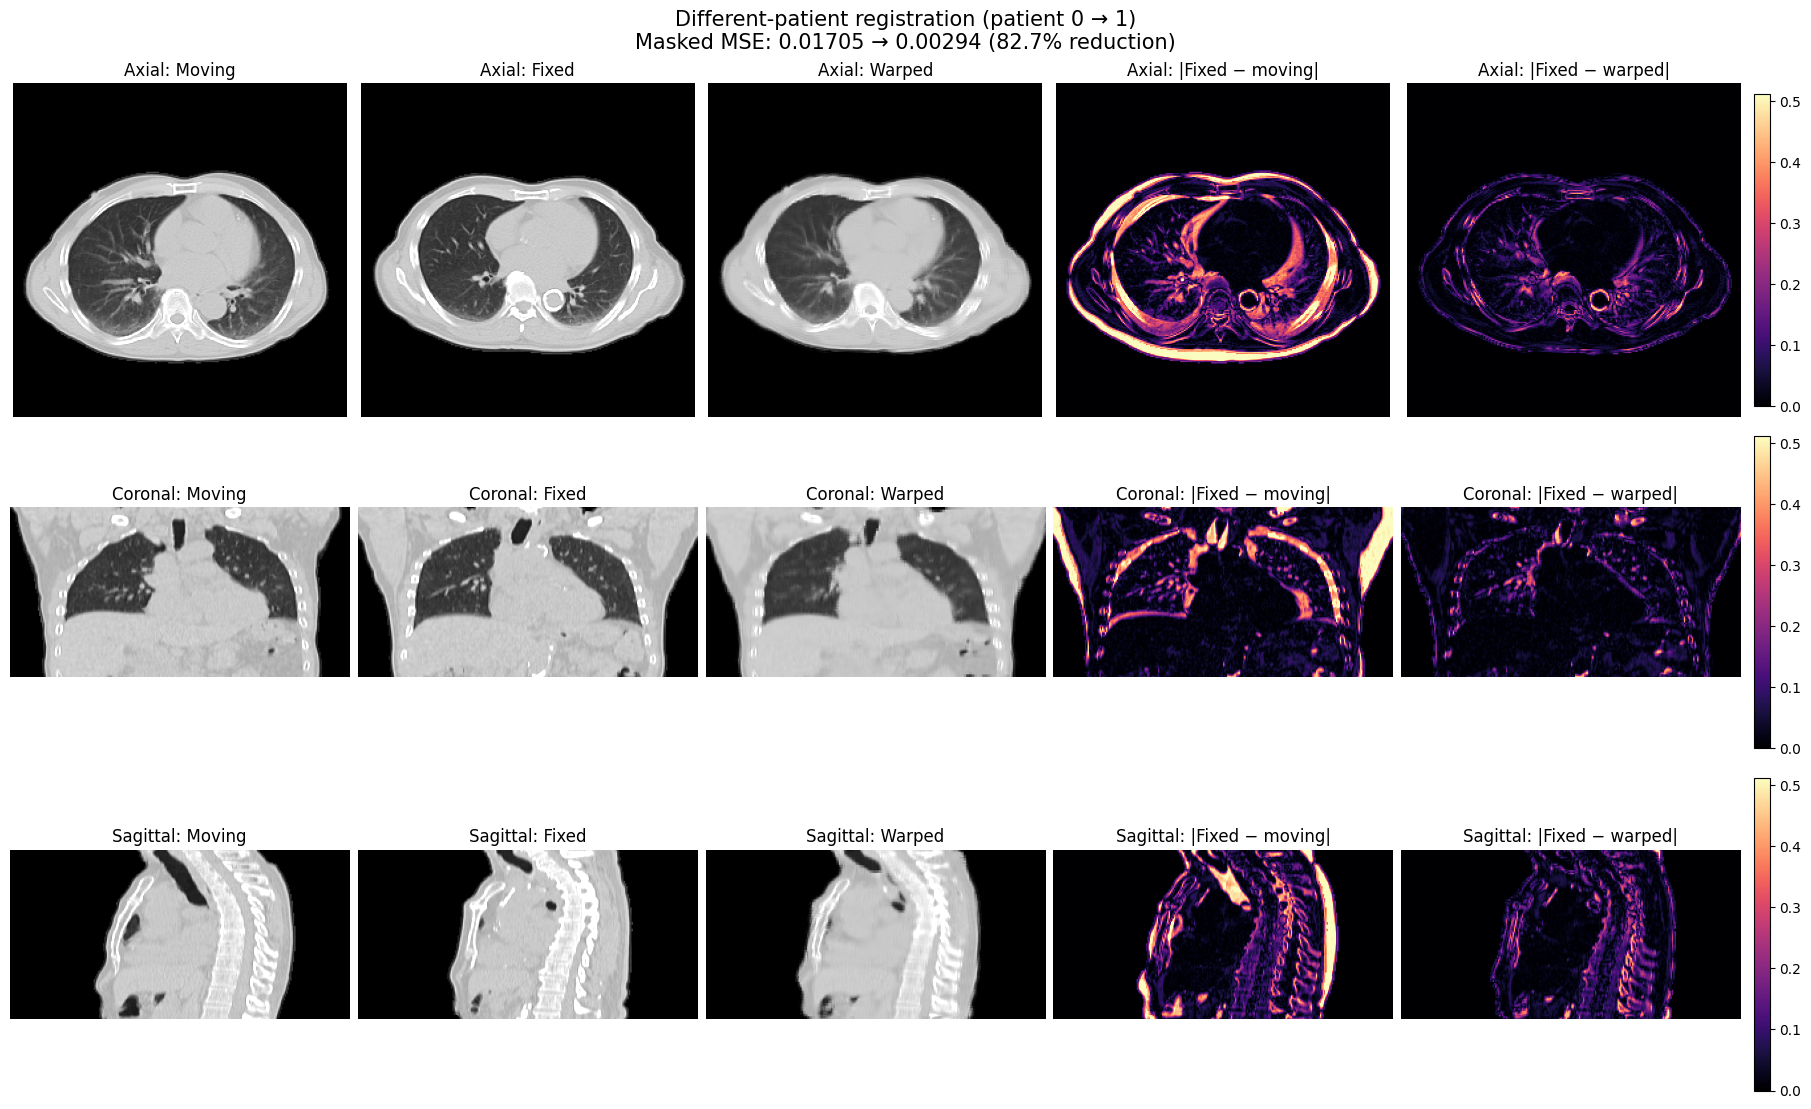

Loaded checkpoint: D:\Saito\finetune_checkpoints_different_patients\finetuned_different_patients_final.pth
Masked MSE: before=0.017049, after=0.002944
Figure saved to: D:\Saito\seminar_registration_before_after.png


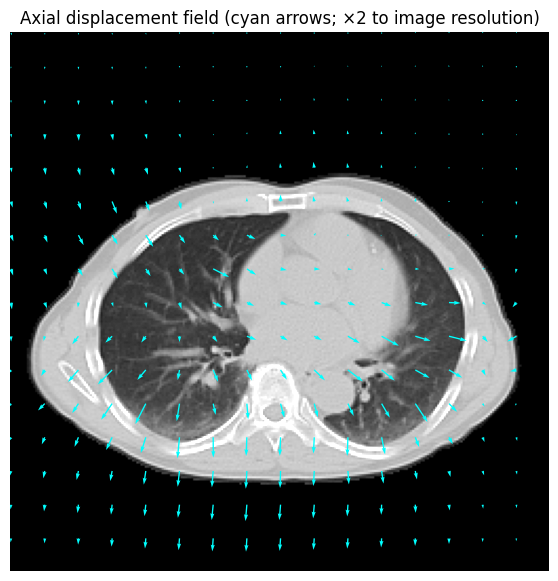

Flow figure saved to: D:\Saito\seminar_displacement_field.png


In [6]:
# Seminar visualization: registration before/after using the completed fine-tuning checkpoint.
# Run the setup and wavelet-pipeline cells before this cell. Fine-tuning is not required here.
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

checkpoint_dir = Path('finetune_checkpoints_different_patients')
final_checkpoint = checkpoint_dir / 'finetuned_different_patients_final.pth'
epoch_30000_checkpoint = checkpoint_dir / 'finetune_epoch_30000.pth'
evaluation_checkpoint = final_checkpoint if final_checkpoint.exists() else epoch_30000_checkpoint
if not evaluation_checkpoint.exists():
    raise FileNotFoundError(
        'Final checkpoint was not found. Expected one of:\n'
        f'  {final_checkpoint.resolve()}\n  {epoch_30000_checkpoint.resolve()}'
    )

try:
    state = torch.load(evaluation_checkpoint, map_location=device, weights_only=True)
except TypeError:
    state = torch.load(evaluation_checkpoint, map_location=device)
model3D.load_state_dict(state['model_state_dict'] if 'model_state_dict' in state else state)
model3D.eval()

# A fixed pair makes the figure reproducible. Change these IDs only when comparing another case.
moving_patient_id, fixed_patient_id = 0, 1
if len(volumes) < 2:
    raise ValueError('At least two patients are required for visualization.')
if moving_patient_id == fixed_patient_id or max(moving_patient_id, fixed_patient_id) >= len(volumes):
    raise ValueError(f'Invalid patient IDs for {len(volumes)} volumes.')

moving_images = torch.from_numpy(volumes[moving_patient_id:moving_patient_id + 1]).unsqueeze(1).to(device)
fixed_images = torch.from_numpy(volumes[fixed_patient_id:fixed_patient_id + 1]).unsqueeze(1).to(device)
overlap_mask = None
if lung_masks is not None:
    overlap_mask = torch.from_numpy(
        lung_masks[moving_patient_id:moving_patient_id + 1] * lung_masks[fixed_patient_id:fixed_patient_id + 1]
    ).unsqueeze(1).to(device)

with torch.no_grad():
    warped_images, flow, _, _, _ = reconstruct_warped(moving_images, fixed_images)
    mse_before = masked_mse(fixed_images, moving_images, overlap_mask).item()
    mse_after = masked_mse(fixed_images, warped_images, overlap_mask).item()

moving_np = moving_images[0, 0].cpu().numpy()
fixed_np = fixed_images[0, 0].cpu().numpy()
warped_np = warped_images[0, 0].cpu().numpy()
before_np = np.abs(fixed_np - moving_np)
after_np = np.abs(fixed_np - warped_np)
flow_np = flow[0].cpu().numpy()

views = [
    ('Axial', lambda a: a[a.shape[0] // 2]),
    ('Coronal', lambda a: a[:, a.shape[1] // 2, :]),
    ('Sagittal', lambda a: a[:, :, a.shape[2] // 2]),
]
image_vmin, image_vmax = np.percentile(np.concatenate([moving_np.ravel(), fixed_np.ravel(), warped_np.ravel()]), [1, 99])
diff_vmax = max(np.percentile(np.concatenate([before_np.ravel(), after_np.ravel()]), 99), 1e-6)

fig, axes = plt.subplots(3, 5, figsize=(18, 11), constrained_layout=True)
for row, (orientation, slicer) in enumerate(views):
    panels = [
        ('Moving', slicer(moving_np), 'gray', image_vmin, image_vmax),
        ('Fixed', slicer(fixed_np), 'gray', image_vmin, image_vmax),
        ('Warped', slicer(warped_np), 'gray', image_vmin, image_vmax),
        ('|Fixed − moving|', slicer(before_np), 'magma', 0, diff_vmax),
        ('|Fixed − warped|', slicer(after_np), 'magma', 0, diff_vmax),
    ]
    for col, (label, image, cmap, vmin, vmax) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f'{orientation}: {label}')
        ax.axis('off')
        if col == 4:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    f'Different-patient registration (patient {moving_patient_id} → {fixed_patient_id})\n'
    f'Masked MSE: {mse_before:.5f} → {mse_after:.5f} '
    f'({(1 - mse_after / mse_before) * 100:.1f}% reduction)',
    fontsize=15,
)
output_figure = Path('seminar_registration_before_after.png')
fig.savefig(output_figure, dpi=200, bbox_inches='tight')
plt.show()
print(f'Loaded checkpoint: {evaluation_checkpoint.resolve()}')
print(f'Masked MSE: before={mse_before:.6f}, after={mse_after:.6f}')
print(f'Figure saved to: {output_figure.resolve()}')

# Flow field on the axial middle slice (arrows are y/x displacement on the downsampled grid).
z = flow_np.shape[1] // 2
step = 8
y, x = np.mgrid[0:flow_np.shape[2]:step, 0:flow_np.shape[3]:step]
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(moving_np[moving_np.shape[0] // 2], cmap='gray', vmin=image_vmin, vmax=image_vmax)
ax.quiver(x * 2, y * 2, flow_np[2, z, ::step, ::step] * 2, flow_np[1, z, ::step, ::step] * 2,
          color='cyan', angles='xy', scale_units='xy', scale=1, width=0.0025)
ax.set_title('Axial displacement field (cyan arrows; ×2 to image resolution)')
ax.axis('off')
flow_figure = Path('seminar_displacement_field.png')
fig.savefig(flow_figure, dpi=200, bbox_inches='tight')
plt.show()
print(f'Flow figure saved to: {flow_figure.resolve()}')


## Checkpoint-wise learning progress (no training)

This cell compares all available saved checkpoints on exactly the same 10 different-patient pairs. It loads weights only and does not update them.


Fixed evaluation pairs: [(77, 283), (55, 347), (399, 234), (59, 276), (171, 289), (50, 167), (308, 293), (115, 215), (164, 129), (168, 269)]


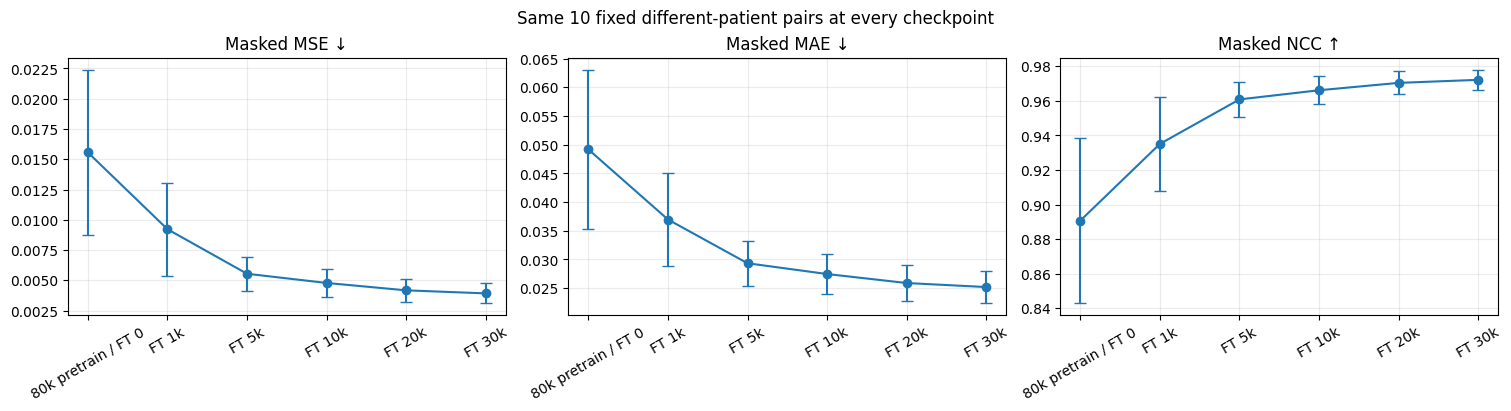

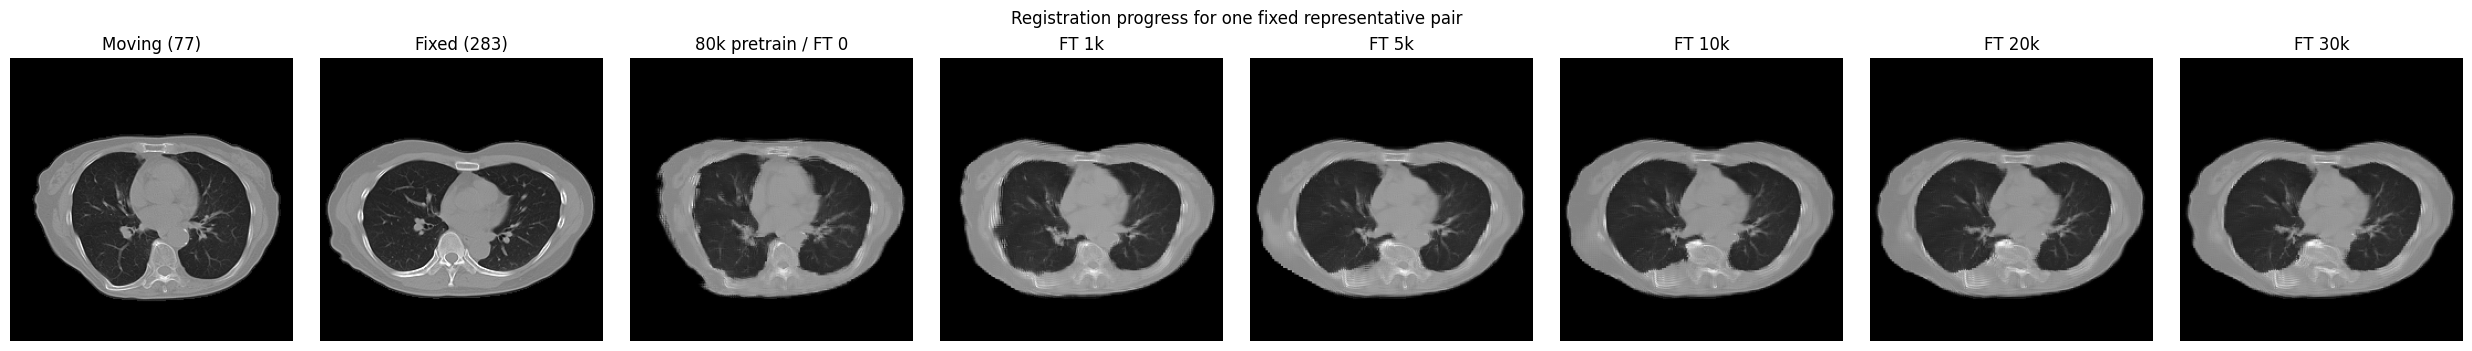

Saved: seminar_checkpoint_metrics.csv, seminar_checkpoint_metric_trends.png, seminar_checkpoint_registration_progress.png


In [7]:
# Checkpoint-wise evaluation: loads weights only; does not train.
import csv
checkpoint_dir = Path('finetune_checkpoints_different_patients')
checkpoint_specs = [
    ('80k pretrain / FT 0', Path('model_analysis_pipeline_pretrain.pth'), 0),
    ('FT 1k', checkpoint_dir / 'finetune_epoch_01000.pth', 1000),
    ('FT 5k', checkpoint_dir / 'finetune_epoch_05000.pth', 5000),
    ('FT 10k', checkpoint_dir / 'finetune_epoch_10000.pth', 10000),
    ('FT 20k', checkpoint_dir / 'finetune_epoch_20000.pth', 20000),
    ('FT 30k', checkpoint_dir / 'finetune_epoch_30000.pth', 30000),
]
checkpoint_specs = [item for item in checkpoint_specs if item[1].exists()]
if not checkpoint_specs:
    raise FileNotFoundError('No checkpoint was found.')

# Reproducible, different-patient pairs; identical pairs at every checkpoint.
rng = np.random.default_rng(20260726)
pairs = []
while len(pairs) < 10:
    moving_id, fixed_id = rng.integers(0, len(volumes), size=2)
    if moving_id != fixed_id:
        pairs.append((int(moving_id), int(fixed_id)))
print('Fixed evaluation pairs:', pairs)

def masked_ncc_eval(target, prediction, mask=None, eps=1e-6):
    if mask is None:
        mask = torch.ones_like(target)
    n = mask.sum().clamp_min(eps)
    target = (target - (target * mask).sum() / n) * mask
    prediction = (prediction - (prediction * mask).sum() / n) * mask
    return (target * prediction).sum() / torch.sqrt(target.square().sum() * prediction.square().sum()).clamp_min(eps)

rows, representative_warped = [], []
for label, path, fine_tuning_epoch in checkpoint_specs:
    try:
        state = torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        state = torch.load(path, map_location=device)
    model3D.load_state_dict(state['model_state_dict'] if 'model_state_dict' in state else state)
    model3D.eval()
    mse, mae, ncc = [], [], []
    with torch.no_grad():
        for moving_id, fixed_id in pairs:
            moving = torch.from_numpy(volumes[moving_id:moving_id + 1]).unsqueeze(1).to(device, dtype=torch.float32)
            fixed = torch.from_numpy(volumes[fixed_id:fixed_id + 1]).unsqueeze(1).to(device, dtype=torch.float32)
            overlap = None if lung_masks is None else torch.from_numpy(lung_masks[moving_id:moving_id + 1] * lung_masks[fixed_id:fixed_id + 1]).unsqueeze(1).to(device, dtype=torch.float32)
            warped, _, _, _, _ = reconstruct_warped(moving, fixed)
            mse.append(masked_mse(fixed, warped, overlap).item())
            mae.append(((fixed - warped).abs().mean() if overlap is None else ((fixed - warped).abs() * overlap).sum() / overlap.sum().clamp_min(1e-6)).item())
            ncc.append(masked_ncc_eval(fixed, warped, overlap).item())
            if (moving_id, fixed_id) == pairs[0]:
                representative_warped.append((label, warped[0, 0].detach().cpu().numpy()))
    rows.append({'checkpoint': label, 'fine_tuning_epoch': fine_tuning_epoch, 'mse_mean': np.mean(mse), 'mse_std': np.std(mse), 'mae_mean': np.mean(mae), 'mae_std': np.std(mae), 'ncc_mean': np.mean(ncc), 'ncc_std': np.std(ncc)})

with open('seminar_checkpoint_metrics.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

x = np.arange(len(rows))
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, metric, title in zip(axes, ['mse', 'mae', 'ncc'], ['Masked MSE ↓', 'Masked MAE ↓', 'Masked NCC ↑']):
    ax.errorbar(x, [row[f'{metric}_mean'] for row in rows], yerr=[row[f'{metric}_std'] for row in rows], marker='o', capsize=4)
    ax.set(xticks=x, xticklabels=[row['checkpoint'] for row in rows], title=title)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.25)
fig.suptitle('Same 10 fixed different-patient pairs at every checkpoint')
fig.savefig('seminar_checkpoint_metric_trends.png', dpi=200, bbox_inches='tight')
plt.show()

moving_id, fixed_id = pairs[0]
fig, axes = plt.subplots(1, len(representative_warped) + 2, figsize=(3.1 * (len(representative_warped) + 2), 3.4), constrained_layout=True)
for ax, title, image in [(axes[0], f'Moving ({moving_id})', volumes[moving_id]), (axes[1], f'Fixed ({fixed_id})', volumes[fixed_id])]:
    ax.imshow(image[image.shape[0] // 2], cmap='gray'); ax.set_title(title); ax.axis('off')
for ax, (label, image) in zip(axes[2:], representative_warped):
    ax.imshow(image[image.shape[0] // 2], cmap='gray'); ax.set_title(label); ax.axis('off')
fig.suptitle('Registration progress for one fixed representative pair')
fig.savefig('seminar_checkpoint_registration_progress.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: seminar_checkpoint_metrics.csv, seminar_checkpoint_metric_trends.png, seminar_checkpoint_registration_progress.png')


## Same-patient longitudinal-22 checkpoint progress (no training)

This cell evaluates the 22 fixed earlier→later pairs from `256_128model_Train.ipynb` at its saved checkpoints. It is separate from the different-patient evaluation and does not train.


Evaluating checkpoints: ['80k pretrain / FT 0', 'Same-patient FT 1k', 'Same-patient FT 5k', 'Same-patient FT 10k', 'Same-patient FT 20k', 'Same-patient FT 30k']


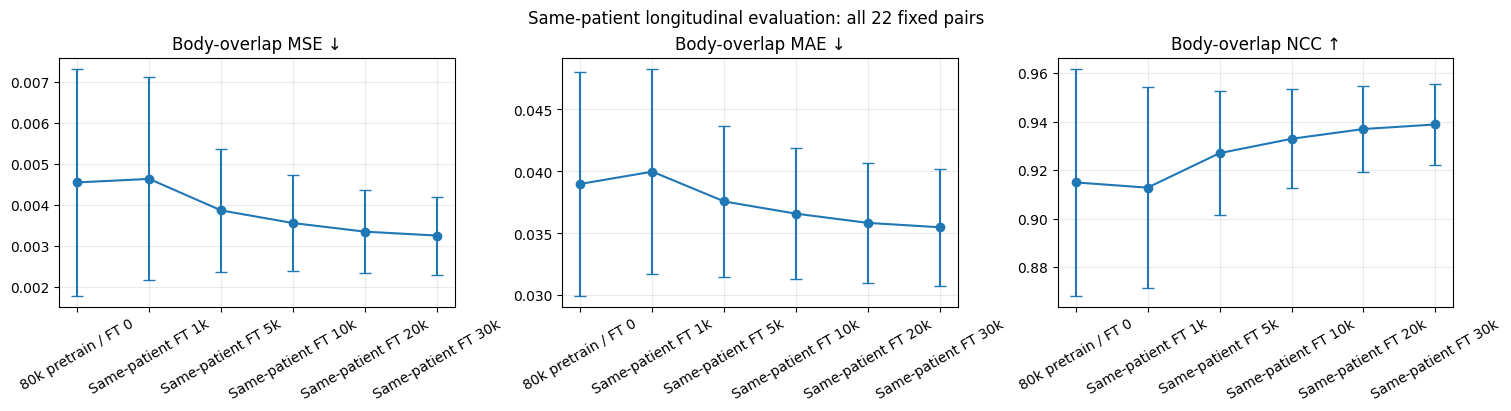

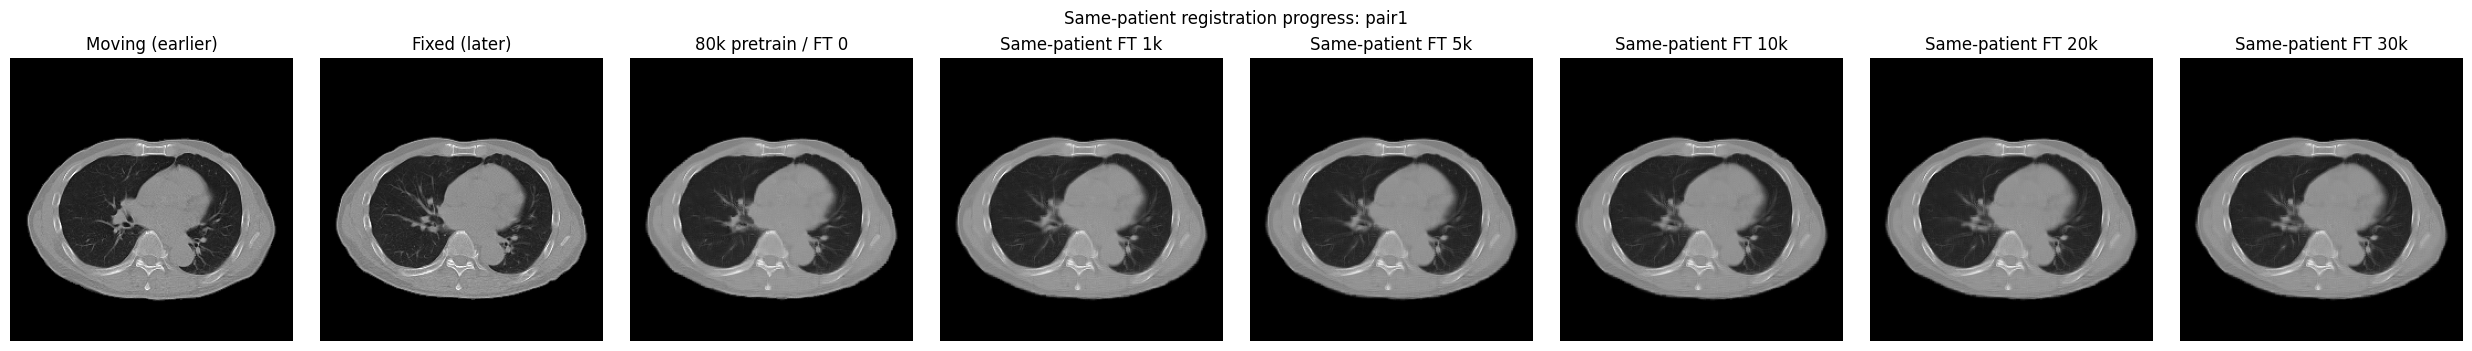

Saved: seminar_same_patient_checkpoint_metrics.csv, seminar_same_patient_checkpoint_metric_trends.png, seminar_same_patient_checkpoint_registration_progress.png


In [8]:
# Same-patient longitudinal-22 checkpoint evaluation: loads weights only; does not train.
import csv
import re

LONGITUDINAL_ROOT = Path('Data/Longitudinal22')
pair_dirs = sorted([path for path in LONGITUDINAL_ROOT.glob('pair*') if path.is_dir()], key=lambda path: int(re.search(r'\d+', path.name).group()))
if len(pair_dirs) != 22:
    raise ValueError(f'Expected 22 longitudinal pairs, found {len(pair_dirs)} in {LONGITUDINAL_ROOT.resolve()}')

same_pairs = []
for pair_dir in pair_dirs:
    moving_paths = list(pair_dir.glob('registered_masked_A_*.npz'))
    fixed_paths = list(pair_dir.glob('fixed_masked_B_*.npz'))
    if len(moving_paths) != 1 or len(fixed_paths) != 1:
        raise ValueError(f'{pair_dir}: expected exactly one moving and fixed NPZ file')
    with np.load(moving_paths[0], allow_pickle=False) as archive:
        moving = np.asarray(archive['Train'], dtype=np.float32)
    with np.load(fixed_paths[0], allow_pickle=False) as archive:
        fixed = np.asarray(archive['Train'], dtype=np.float32)
    if moving.shape != (128, 256, 256) or fixed.shape != (128, 256, 256):
        raise ValueError(f'{pair_dir}: unexpected volume shape')
    same_pairs.append((pair_dir.name, moving, fixed))

same_checkpoint_dir = Path('.')
same_specs = [
    ('80k pretrain / FT 0', Path('model_analysis_pipeline_pretrain.pth'), 0),
    ('Same-patient FT 1k', same_checkpoint_dir / 'model_analysis_pipeline_finetuned_epoch1000.pth', 1000),
    ('Same-patient FT 5k', same_checkpoint_dir / 'model_analysis_pipeline_finetuned_epoch5000.pth', 5000),
    ('Same-patient FT 10k', same_checkpoint_dir / 'model_analysis_pipeline_finetuned_epoch10000.pth', 10000),
    ('Same-patient FT 20k', same_checkpoint_dir / 'model_analysis_pipeline_finetuned_epoch20000.pth', 20000),
    ('Same-patient FT 30k', same_checkpoint_dir / 'model_analysis_pipeline_finetuned_epoch30000.pth', 30000),
]
same_specs = [item for item in same_specs if item[1].exists()]
if not same_specs:
    raise FileNotFoundError('No same-patient checkpoints were found beside this notebook.')
print('Evaluating checkpoints:', [label for label, _, _ in same_specs])

def same_pair_metrics(fixed, warped, mask, eps=1e-6):
    count = mask.sum().clamp_min(eps)
    error = fixed - warped
    mse = (error.square() * mask).sum() / count
    mae = (error.abs() * mask).sum() / count
    fixed_mean = (fixed * mask).sum() / count
    warped_mean = (warped * mask).sum() / count
    fixed_centered = (fixed - fixed_mean) * mask
    warped_centered = (warped - warped_mean) * mask
    ncc = (fixed_centered * warped_centered).sum() / torch.sqrt(fixed_centered.square().sum() * warped_centered.square().sum()).clamp_min(eps)
    return mse.item(), mae.item(), ncc.item()

same_rows, same_representative = [], []
for label, checkpoint_path, fine_tuning_epoch in same_specs:
    try:
        state = torch.load(checkpoint_path, map_location=device, weights_only=True)
    except TypeError:
        state = torch.load(checkpoint_path, map_location=device)
    model3D.load_state_dict(state['model_state_dict'] if isinstance(state, dict) and 'model_state_dict' in state else state)
    model3D.eval()
    mse_values, mae_values, ncc_values = [], [], []
    with torch.no_grad():
        for pair_index, (_pair_name, moving_np, fixed_np) in enumerate(same_pairs):
            moving = torch.from_numpy(moving_np).unsqueeze(0).unsqueeze(0).to(device)
            fixed = torch.from_numpy(fixed_np).unsqueeze(0).unsqueeze(0).to(device)
            # Restrict scores to the common non-background body region.
            body_overlap = ((moving > 0) & (fixed > 0)).to(dtype=torch.float32)
            warped, _, _, _, _ = reconstruct_warped(moving, fixed)
            mse, mae, ncc = same_pair_metrics(fixed, warped, body_overlap)
            mse_values.append(mse); mae_values.append(mae); ncc_values.append(ncc)
            if pair_index == 0:
                same_representative.append((label, warped[0, 0].cpu().numpy()))
    same_rows.append({'checkpoint': label, 'fine_tuning_epoch': fine_tuning_epoch,
                      'mse_mean': np.mean(mse_values), 'mse_std': np.std(mse_values),
                      'mae_mean': np.mean(mae_values), 'mae_std': np.std(mae_values),
                      'ncc_mean': np.mean(ncc_values), 'ncc_std': np.std(ncc_values)})

with open('seminar_same_patient_checkpoint_metrics.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=same_rows[0].keys())
    writer.writeheader(); writer.writerows(same_rows)

x = np.arange(len(same_rows))
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, metric, title in zip(axes, ['mse', 'mae', 'ncc'], ['Body-overlap MSE ↓', 'Body-overlap MAE ↓', 'Body-overlap NCC ↑']):
    ax.errorbar(x, [row[f'{metric}_mean'] for row in same_rows], yerr=[row[f'{metric}_std'] for row in same_rows], marker='o', capsize=4)
    ax.set(xticks=x, xticklabels=[row['checkpoint'] for row in same_rows], title=title)
    ax.tick_params(axis='x', rotation=30); ax.grid(alpha=0.25)
fig.suptitle('Same-patient longitudinal evaluation: all 22 fixed pairs')
fig.savefig('seminar_same_patient_checkpoint_metric_trends.png', dpi=200, bbox_inches='tight')
plt.show()

pair_name, moving_np, fixed_np = same_pairs[0]
fig, axes = plt.subplots(1, len(same_representative) + 2, figsize=(3.1 * (len(same_representative) + 2), 3.4), constrained_layout=True)
for ax, title, image in [(axes[0], 'Moving (earlier)', moving_np), (axes[1], 'Fixed (later)', fixed_np)]:
    ax.imshow(image[image.shape[0] // 2], cmap='gray'); ax.set_title(title); ax.axis('off')
for ax, (label, image) in zip(axes[2:], same_representative):
    ax.imshow(image[image.shape[0] // 2], cmap='gray'); ax.set_title(label); ax.axis('off')
fig.suptitle(f'Same-patient registration progress: {pair_name}')
fig.savefig('seminar_same_patient_checkpoint_registration_progress.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: seminar_same_patient_checkpoint_metrics.csv, seminar_same_patient_checkpoint_metric_trends.png, seminar_same_patient_checkpoint_registration_progress.png')


## Perfect-reconstruction validation

This cell checks zero-flow image reconstruction and the Haar filter-bank alias-cancellation, amplitude, and phase conditions. It does **not** train.



========== Downsampled Wavelet PR Validation ==========
A. Zero-flow end-to-end reconstruction
   input / bands / downsampled: (1, 1, 128, 256, 256) / (1, 8, 128, 256, 256) / (1, 8, 64, 128, 128)
   MAE=3.968e-08, MSE=5.188e-15, max_abs_error=4.172e-07 -> OK

B. Condition 1 -- alias cancellation
   max |H0(w+pi)F0(w) + H1(w+pi)F1(w)| = 3.554e-16 -> OK
C. Condition 2 -- amplitude reconstruction
   max ||T(w)| - 1| = 6.661e-16 -> OK
D. Condition 3 -- phase reconstruction (delay only)
   expected T(w)=exp(-j*w), max |T(w)-exp(-j*w)| = 4.743e-16 -> OK

3D conclusion: the same Haar bank is used independently on z, y, and x; therefore all three 1D conditions apply to each axis.
OVERALL: OK


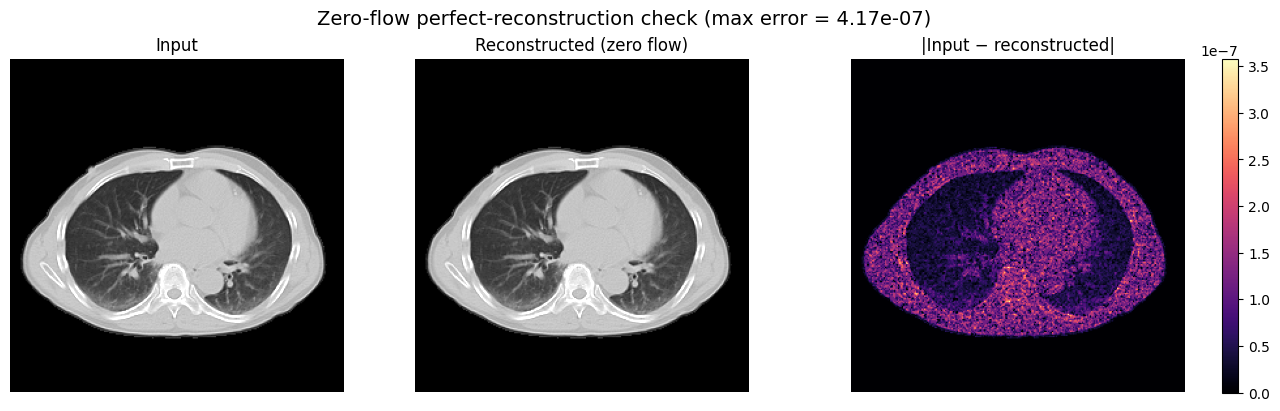

Figure saved to: seminar_perfect_reconstruction.png


In [9]:
# Downsampled Haar Wavelet: zero-flow reconstruction and PR conditions
# Run this after the wavelet-pipeline cell (analysis, synthesis_filters, volumes, and device are defined).
import numpy as np
import torch

print('\n========== Downsampled Wavelet PR Validation ==========')

# A. End-to-end zero-flow check on a training volume.  No registration model is used here.
if 'volumes' in globals():
    pr_source = volumes
elif 'x_train' in globals():
    pr_source = x_train
else:
    raise RuntimeError('Run the data-loading/fine-tuning cell first: volumes (or x_train) is required.')

pr_x = torch.as_tensor(pr_source[0:1], dtype=torch.float32, device=device).unsqueeze(1)
with torch.no_grad():
    pr_bands = analysis_filter_3d(pr_x, analysis)
    pr_down = down_sampling_3d(pr_bands)
    pr_up = up_sampling_3d(pr_down)
    pr_reconstructed, _ = synthesis_filter_3d(pr_up, synthesis_filters)

if pr_x.shape != pr_reconstructed.shape:
    raise RuntimeError(f'Shape mismatch: input={tuple(pr_x.shape)}, reconstructed={tuple(pr_reconstructed.shape)}')
pr_error = pr_x - pr_reconstructed
pr_mae = pr_error.abs().mean().item()
pr_mse = pr_error.square().mean().item()
pr_max = pr_error.abs().max().item()
pr_zero_flow_ok = pr_max < 1e-5
print('A. Zero-flow end-to-end reconstruction')
print(f'   input / bands / downsampled: {tuple(pr_x.shape)} / {tuple(pr_bands.shape)} / {tuple(pr_down.shape)}')
print(f'   MAE={pr_mae:.3e}, MSE={pr_mse:.3e}, max_abs_error={pr_max:.3e} -> {"OK" if pr_zero_flow_ok else "NG"}')

# B--D. Theoretical two-channel biorthogonal PR conditions for each separable axis.
# A(z): analysis filters H0, H1; S(z): synthesis filters F0, F1.
# For critically sampled filter banks:
#   (1) H0(e^(j(w+pi)))F0(e^(jw)) + H1(e^(j(w+pi)))F1(e^(jw)) = 0
#   (2) 1/2 * [H0(e^(jw))F0(e^(jw)) + H1(e^(jw))F1(e^(jw))] = c exp(-j*w*n0)
# Condition (2) is checked as constant magnitude and a pure integer-sample delay (linear phase).
sqrt2 = np.sqrt(2.0)
h0 = np.array([1.0, 1.0]) / sqrt2
h1 = np.array([-1.0, 1.0]) / sqrt2  # analysis high-pass (correlation convention)
f0 = np.array([1.0, 1.0]) / sqrt2
f1 = np.array([1.0, -1.0]) / sqrt2  # synthesis high-pass
omega = np.linspace(-np.pi, np.pi, 4096, endpoint=False)
def response(h, w):
    n = np.arange(len(h))
    return np.sum(h[None, :] * np.exp(-1j * w[:, None] * n[None, :]), axis=1)

H0, H1 = response(h0, omega), response(h1, omega)
F0, F1 = response(f0, omega), response(f1, omega)
H0_alias, H1_alias = response(h0, omega + np.pi), response(h1, omega + np.pi)
alias = H0_alias * F0 + H1_alias * F1
transfer = 0.5 * (H0 * F0 + H1 * F1)
expected_delay = np.exp(-1j * omega)  # Haar bank: gain 1, one-sample delay

tol = 1e-10
alias_max = np.abs(alias).max()
amplitude_error = np.abs(np.abs(transfer) - 1.0).max()
delay_error = np.abs(transfer - expected_delay).max()
alias_ok = alias_max < tol
amplitude_ok = amplitude_error < tol
phase_ok = delay_error < tol

print('\nB. Condition 1 -- alias cancellation')
print(f'   max |H0(w+pi)F0(w) + H1(w+pi)F1(w)| = {alias_max:.3e} -> {"OK" if alias_ok else "NG"}')
print('C. Condition 2 -- amplitude reconstruction')
print(f'   max ||T(w)| - 1| = {amplitude_error:.3e} -> {"OK" if amplitude_ok else "NG"}')
print('D. Condition 3 -- phase reconstruction (delay only)')
print(f'   expected T(w)=exp(-j*w), max |T(w)-exp(-j*w)| = {delay_error:.3e} -> {"OK" if phase_ok else "NG"}')
print('\n3D conclusion: the same Haar bank is used independently on z, y, and x; therefore all three 1D conditions apply to each axis.')
print('OVERALL:', 'OK' if all((pr_zero_flow_ok, alias_ok, amplitude_ok, phase_ok)) else 'NG -- inspect boundary handling and filter conventions.')


# Seminar-friendly reconstruction figure (middle axial slice)
pr_slice = pr_x.shape[2] // 2
pr_input_image = pr_x[0, 0, pr_slice].detach().cpu().numpy()
pr_output_image = pr_reconstructed[0, 0, pr_slice].detach().cpu().numpy()
pr_error_image = np.abs(pr_input_image - pr_output_image)
pr_vmin, pr_vmax = np.percentile(pr_input_image, [1, 99])
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, title, image, cmap, vmin, vmax in [
    (axes[0], 'Input', pr_input_image, 'gray', pr_vmin, pr_vmax),
    (axes[1], 'Reconstructed (zero flow)', pr_output_image, 'gray', pr_vmin, pr_vmax),
    (axes[2], '|Input − reconstructed|', pr_error_image, 'magma', 0, max(pr_error_image.max(), 1e-8)),
]:
    im = ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')
    if title.startswith('|'):
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f'Zero-flow perfect-reconstruction check (max error = {pr_max:.2e})', fontsize=14)
fig.savefig('seminar_perfect_reconstruction.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure saved to: seminar_perfect_reconstruction.png')
